In [1]:
import numpy as np
import hockey.hockey_env as h_env
import gymnasium as gym
from importlib import reload
import time

In [2]:
np.set_printoptions(suppress=True)

In [3]:
reload(h_env)

/home/tomf/.pyenv/versions/3.12.5/envs/reinforce-the-puck/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment Hockey-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/tomf/.pyenv/versions/3.12.5/envs/reinforce-the-puck/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment Hockey-One-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


<module 'hockey.hockey_env' from '/home/tomf/.pyenv/versions/3.12.5/envs/reinforce-the-puck/lib/python3.12/site-packages/hockey/hockey_env.py'>

# Normal Game Play

In [4]:
env = h_env.HockeyEnv()

have a look at the initialization condition: alternating who starts and are random in puck position

In [5]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
_ = env.render()

one episode with random agents

In [11]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()

for _ in range(600):
    env.render(mode="human")
    a1 = np.random.uniform(-1, 1, 4)
    a2 = np.random.uniform(-1, 1, 4)
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

Without rendering, it runs much faster

"info" dict contains useful proxy rewards and winning information

In [12]:
info, env.get_info_agent_two()

({'winner': 0,
  'reward_closeness_to_puck': -0.12452278028691217,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.0},
 {'winner': 0,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.0})

Winner == 0: draw

Winner == 1: you (left player)

Winner == -1: opponent wins (right player)

In [13]:
env.close()

# Train Shooting

In [84]:
env = h_env.HockeyEnv(mode=1)

In [ ]:
o, info = env.reset()
_ = env.render()

for _ in range(1000):
    env.render()
    a1 = [1, 0, 0, 1]  # np.random.uniform(-1,1,4)
    a2 = [0, 0.0, 0, 0]
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

: 

In [83]:
env.close()

# Train DEFENDING

In [30]:
env = h_env.HockeyEnv(mode=2)

In [39]:
o, info = env.reset()
_ = env.render()

for _ in range(60):
    env.render()
    a1 = [0.1, 0, 0, 1]  # np.random.uniform(-1,1,3)
    a2 = [0, 0.0, 0, 0]
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    print(r)
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

-0.5299462728972005
-0.3766336009324717
-0.272066563169353
-0.21891445389142852
-0.2133037670457465
-0.24444670532542495
-10.301374597388852


In [40]:
env.close()

# Using discrete actions

In [41]:
import random

In [42]:
env = h_env.HockeyEnv(mode=1)

In [44]:
env.reset()
for _ in range(251):
    env.render()
    a1_discrete = random.randint(0, 7)
    a1 = env.discrete_to_continous_action(a1_discrete)
    a2 = [0, 0.0, 0, 0]
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break

KeyboardInterrupt: 

In [45]:
env.close()

# Hand-crafted Opponent

In [46]:
env = h_env.HockeyEnv()

In [47]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent()

In [48]:
obs_buffer = []
reward_buffer = []
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
for _ in range(251):
    env.render()
    a1 = player1.act(obs)
    a2 = player2.act(obs_agent2)
    obs, r, d, t, info = env.step(np.hstack([a1, a2]))
    obs_buffer.append(obs)
    reward_buffer.append(r)
    obs_agent2 = env.obs_agent_two()
    if d or t:
        break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)

In [49]:
np.mean(obs_buffer, axis=0)

array([-3.20161361, -0.04472183, -0.02711912, -0.06737352, -0.12830593,
        0.06500216,  3.17316591, -0.20668294,  0.01148299,  0.00068326,
        0.0630235 , -0.03960298, -0.39833074, -0.26219819,  0.18368363,
       -0.04704325,  0.41832669,  0.        ])

In [50]:
np.std(obs_buffer, axis=0)

array([ 0.48076148,  1.00727593,  0.59711951,  3.38629702,  6.48690285,
        3.77844882,  0.38358743,  0.45465589,  0.14425002,  2.60882947,
        1.97706704,  0.72777515,  1.43934842,  1.72510851,  5.82370739,
       12.8820431 ,  2.13216283,  0.        ])

If you want to use a fixed observation scaling, this might be a reasonable choice

In [53]:
scaling = [
    1.0,
    1.0,
    0.5,
    4.0,
    4.0,
    4.0,
    1.0,
    1.0,
    0.5,
    4.0,
    4.0,
    4.0,
    2.0,
    2.0,
    10.0,
    10.0,
    4,
    0,
    4,
    0,
]

In [54]:
import pylab as plt

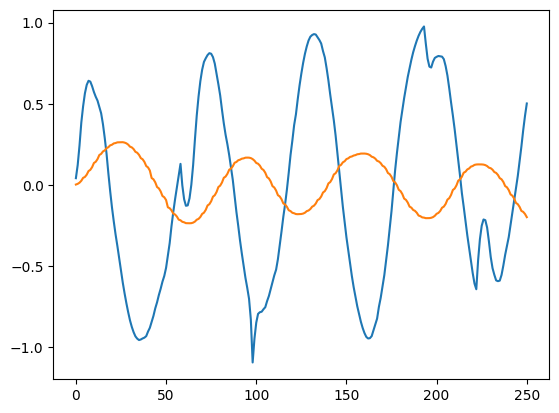

In [55]:
plt.plot(obs_buffer[:, 2])
plt.plot(obs_buffer[:, 8])

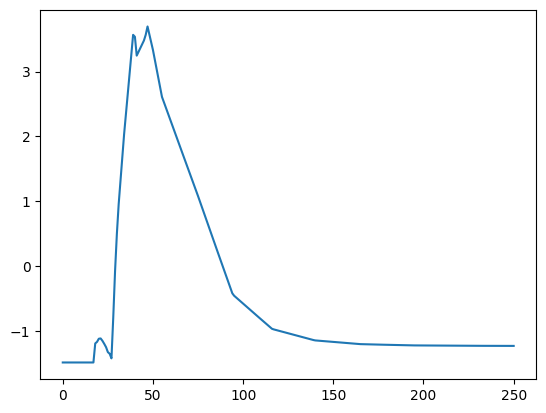

In [56]:
plt.plot(obs_buffer[:, 12])

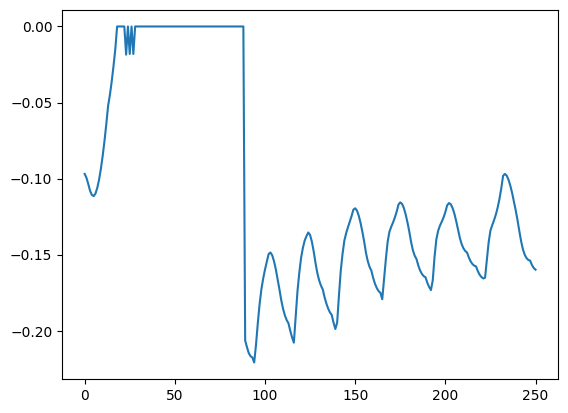

In [57]:
plt.plot(reward_buffer[:])

In [58]:
np.sum(reward_buffer)

-26.15775657147229

In [59]:
info2 = env.get_info_agent_two()
info, info2, env.get_reward(info), env.get_reward_agent_two(info2)

({'winner': 0,
  'reward_closeness_to_puck': -0.15988350907801896,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -5.048495531082153e-07},
 {'winner': 0,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 5.048495531082153e-07},
 -0.15988350907801896,
 0.0)

In [60]:
env.close()

# Human Opponent

In [61]:
env = h_env.HockeyEnv()

In [62]:
player1 = h_env.HumanOpponent(env=env, player=1)
player2 = h_env.BasicOpponent()

Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [63]:
player1 = h_env.BasicOpponent()
player2 = h_env.HumanOpponent(env=env, player=2)

Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [64]:
obs, info = env.reset()

env.render()
time.sleep(1)
obs_agent2 = env.obs_agent_two()
for _ in range(100):
    time.sleep(0.2)
    env.render()
    a1 = player1.act(obs)
    a2 = player2.act(obs_agent2)
    obs, r, d, _, info = env.step(np.hstack([a1, a2]))
    obs_agent2 = env.obs_agent_two()
    if d:
        break

In [69]:
env.close()

# Check side consistency

In [70]:
env = h_env.HockeyEnv()

In [71]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent(weak=False)

In [72]:
obs_buffer = []
reward_buffer = []
obs2_buffer = []
winner_buffer = []
reward2_buffer = []
for game in range(1000):
    obs, info = env.reset()
    obs_agent2 = env.obs_agent_two()
    for _ in range(500):
        # env.render()
        a1 = player1.act(obs)
        a2 = player2.act(obs_agent2)
        #        a1 = np.random.uniform(-1,1,4)
        #        a2 = np.random.uniform(-1,1,4)
        obs, r, d, t, info = env.step(np.hstack([a1, a2]))
        info2 = env.get_info_agent_two()
        r2 = env.get_reward_agent_two(info2)
        obs_buffer.append(obs)
        obs_agent2 = env.obs_agent_two()
        obs2_buffer.append(obs_agent2)
        reward_buffer.append(r)
        reward2_buffer.append(r2)
        if d or t:
            winner_buffer.append(info["winner"])
            break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)
obs2_buffer = np.asarray(obs2_buffer)
reward2_buffer = np.asarray(reward2_buffer)

In [73]:
obs_buffer.shape

(151565, 18)

In [74]:
np.mean(obs_buffer, axis=0)

array([-2.97888106,  0.00001797, -0.00132799, -0.05613033,  0.01595334,
       -0.01055253,  2.97794889,  0.00667539, -0.00167648,  0.05204013,
        0.0126001 , -0.00480013, -0.01689268,  0.01444878,  0.03788336,
        0.00988088,  1.08557385,  1.09107644])

In [75]:
(np.std(obs_buffer, axis=0) - np.std(obs2_buffer, axis=0)) / np.std(obs_buffer, axis=0)

array([-0.00048196, -0.01675039, -0.00086126,  0.00185331, -0.01168299,
        0.00219509,  0.00048173,  0.01647443,  0.00086052, -0.00185675,
        0.01154807, -0.00219992,  0.        ,  0.        ,  0.        ,
        0.        , -0.00227019,  0.00226505])

In [76]:
winner_buffer

[-1,
 -1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 -1,
 0,
 0,
 1,
 0,
 -1,
 1,
 0,
 -1,
 0,
 -1,
 0,
 1,
 0,
 -1,
 1,
 0,
 1,
 -1,
 0,
 0,
 1,
 1,
 0,
 1,
 -1,
 1,
 1,
 -1,
 0,
 -1,
 1,
 0,
 1,
 0,
 0,
 1,
 -1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 -1,
 0,
 0,
 0,
 -1,
 0,
 -1,
 0,
 -1,
 0,
 -1,
 -1,
 -1,
 1,
 -1,
 0,
 0,
 1,
 -1,
 1,
 1,
 -1,
 0,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 -1,
 0,
 1,
 1,
 -1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 -1,
 1,
 1,
 1,
 0,
 -1,
 1,
 1,
 -1,
 1,
 0,
 1,
 0,
 -1,
 -1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 -1,
 0,
 0,
 0,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 -1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 -1,
 1,
 -1,
 0,
 -1,
 -1,
 1,
 -1,
 -1,
 0,
 -1,
 0,
 1,
 1,
 -1,
 0,
 1,
 1,
 -1,
 1,
 0,
 1,
 0,
 -1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 -1,
 1,
 1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 0,
 0,
 1,
 1,
 -1,
 0,
 1,
 0,
 1,
 -1,
 -1,
 1,
 0,
 0,
 -1,
 0,
 -1,
 

In [77]:
np.mean(winner_buffer, axis=0)

0.028

In [78]:
np.std(winner_buffer, axis=0)

0.8044973586034948

In [79]:
np.sum(reward_buffer), np.sum(reward2_buffer)

(-4117.950451598011, -4617.018920846469)

In [80]:
env.close()